In [1]:
import xarray as xr
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
import os, sys, glob, json, itertools

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")


In [2]:
#this is year and month for which trigger model will be run

year=2026
month=4

datadir="./data/"


monthnames=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
#shapefile with provinces
studyarea = gpd.read_file("{}/gis/study_area.shp".format(datadir))
studyregions=studyarea["NAME_1"]

In [4]:
#load drought data
droughts=pd.read_csv("{}/zonal_data/observed_droughts.csv".format(datadir), parse_dates=True, index_col=0)
droughts=droughts["drought"]

#we are interested in droughts in May
droughtsMay=droughts.copy()
droughtsMay.index=droughts.index+pd.offsets.MonthBegin(4)


In [5]:
#load predictor data
file="{}/all_zonal/alldata_{}{}.csv".format(datadir, year, str(month).zfill(2))
print(file)
alldata=pd.read_csv(file, header=[0,1], parse_dates=True, index_col=0)

./data//all_zonal/alldata_202604.csv


In [7]:
#show data for selected province - just to see what data are available cur
reg="Faryab"
alldata.xs(reg, level="province", axis=1).loc["{}-{}-01".format(year, str(month).zfill(2))]

variable
enso          -0.060000
LST          287.699069
pr-fcst_2      3.921569
pr-fcst_3     27.450980
pr-fcst_4     47.058824
pr-fcst_5     27.450980
spi6_era5     -0.878753
Name: 2026-04-01 00:00:00, dtype: float64

In [8]:
#
# in the forecast model the following is considered
#
# 1) X is predictor taken from alldata, and in that data frame dates are set so that predictor for given month 
#    sourced from monitoring is the value that was recorded the previous month, i.e.
#    value given for April is the measurement for March.
#    for a variable represnting a forecast - it is the value of the forecast issued that month, i.e. value for April 
#    is for the forecas issued on the 8th of April.
# 2) the target month (tgtmon) is typically May - as it corresponds to the end of rains and the Mar-May critical period for crop and pasture growth 
#    identified droughts are aligned to May
# 3) in order to enable an easy selection of predictors and predictand at various lead times, 
#    predictor time is offset to align it with the target time
# 4) lead time of this model (lt) is calculated in months prior to target month. If target month is May, 
#    lead time of 3 is for forecast issued in March. 
# 5) Because of pythonic notation of lead time in 
#    variables sourced from dynamical forecast models, lt-1 is used to select appropriate variable: fcst_{}
#    In this way, the variable sourced from dynamical forecast represents that forecast for a three month 
#    period ending on target month.  
# 6) the first line below aligns dates in predictor time series so that predictor month aligns with target month
#    since the alignment is done on the entire time series of predictors, the second line - selects 
#    predictor data corresponding to the target month 
#    X.index=X.index+pd.offsets.MonthBegin(lt-1)
#    X=X[X.index.month==tgtmon]

## forecast with full dataset, i.e. including current year

trigger month: April
lead time: 3
target month: 6
predictor 2000-06-01 00:00:00 2026-06-01 00:00:00
['pr-fcst_2', 'LST', 'spi6_era5'] [ 0.70745696  1.16440539 -1.41212406]
0.13341726052777445
fullX 2000-05-01 00:00:00
(array([26]),)
26
trigger month: March
lead time: 3
target month: 5
predictor 2000-05-01 00:00:00 2026-05-01 00:00:00
['pr-fcst_2', 'enso', 'spi6_era5'] [ 1.11292055 -0.71470758 -0.90135695]
0.41645193770131567
fullX 2000-04-01 00:00:00
(array([26]),)
26
trigger month: February
lead time: 4
target month: 5
predictor 2000-05-01 00:00:00 2026-05-01 00:00:00
['pr-fcst_2', 'enso', 'spi6_era5'] [ 0.48320168 -1.09166853 -0.49366115]
0.7250098617173112
fullX 2000-03-01 00:00:00
(array([26]),)
26
trigger month: January
lead time: 5
target month: 5
predictor 2000-05-01 00:00:00 2026-05-01 00:00:00
['pr-fcst_2', 'enso', 'spi6_era5'] [ 0.21766514 -1.33567513 -0.53156959]
0.6411699533968046
fullX 2000-02-01 00:00:00
(array([26]),)
26


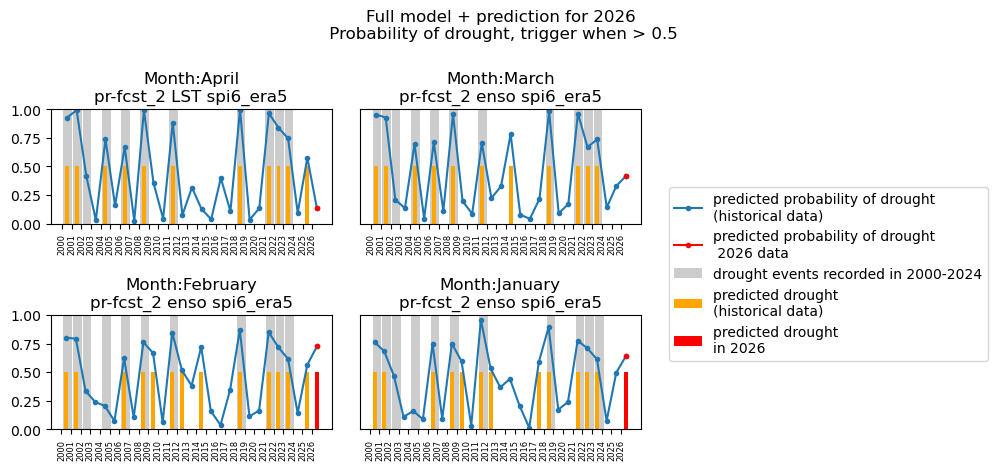

In [17]:
#this is forecast with current values, so based on predictors extending beyond the model calibration period


#this defines a set of variables used in each of the months in which trigger is to be evaluated    
varsets={"April":[6,3,['pr-fcst_2', 'LST','spi6_era5']],
             "March":[5,3,['pr-fcst_2','enso','spi6_era5']],
             "February":[5,4,['pr-fcst_2','enso','spi6_era5']],
             "January":[5,5,['pr-fcst_2','enso','spi6_era5']]}


    
fig=plt.figure(figsize=(10,5))

#regression model category - we will use logistic regression
model=LogisticRegression()


fullpred={}

#iterating through the months for which trigger model is relevant
for i,mon in enumerate(varsets.keys()):
    
    tgtmon,lt,finalvars=varsets[mon]
    print("trigger month: {}\nlead time: {}\ntarget month: {}".format(mon, lt, tgtmon))
    
    pl=fig.add_subplot(2,2,i+1)

    X=alldata[finalvars].xs(reg, level="province", axis=1).copy()
 
    #predictor - we are aligning predictor date to target date
    X.index=X.index+pd.offsets.MonthBegin(lt-1)
    
    #selecting only predictors corresponding to target month
    X=X[X.index.month==tgtmon]
    
    X=X.dropna(axis=0)
    
    print("predictor dates:", X.index[0], X.index[-1])
    
    
    scaler = StandardScaler()
    X[:] = scaler.fit_transform(X)
    fullX=X.copy()
    
    y = droughtsMay.copy()
    
    # this is a workaround allowing event data to be available only for one month of the year, i.e. May, to be used 
    # in predicting events aligned with other months
    y.index=y.index+pd.offsets.MonthBegin(tgtmon-5)
    
    #finding overlap of X and Y data
    sel=np.intersect1d(X.index, y.index)
    X=X.loc[sel]
    y=y.loc[sel]
    
    
    #full model
    #fitting model
    model.fit(X,y)
    print(finalvars, model.coef_[0])

    #applying model to all -full - data
    y_pred_full = model.predict(fullX)
    
    fullpred[mon]=y_pred_full
    
    # probability of drought calculated from the fitted model 
    probability=model.predict_proba(fullX)[:,1]
    print(probability[-1])
    
    fullX.index=fullX.index-pd.offsets.MonthBegin(lt-2)
    print("fullX", fullX.index[0])
    
    #offset here is not relevant, as it is just for plotting
    pl.bar(y.index+pd.offsets.Day(182), y.values, width=330, color="0.8", label="drought events recorded in 2000-2024")
    pl.bar(fullX.index+pd.offsets.Day(182), y_pred_full/2, width=150, color="orange", label="predicted drought \n(historical data)")

    currentidx=np.where(fullX.index.year==year)
    print(currentidx)
    if len(currentidx[0])>0:
        currentidx=currentidx[0][0]
        print(currentidx)
        pl.bar((fullX.index+pd.offsets.Day(182))[currentidx], (y_pred_full/2)[currentidx], width=150, color="red", label="predicted drought \nin {}".format(year))
        
    pl.plot(fullX.index+pd.offsets.Day(182), probability, "-o", label="predicted probability of drought\n(historical data)".format(year), markersize=3)
    
    pl.plot((fullX.index+pd.offsets.Day(182))[currentidx], probability[currentidx], "-o", color="red", label="predicted probability of drought \n {} data".format(year), markersize=3)

    pl.set_ylim(0,1)
    if i in [1,3]:
        pl.set_yticks([])
    pl.set_xticklabels(fullX.index.year, fontdict={"fontsize":6})
        
    pl.set_xticks(fullX.index)
    plt.xticks(rotation=90)
    pl.set_title("Month:{}\n{}".format(mon," ".join(finalvars)))
    #sys.exit()
plt.suptitle("Full model + prediction for {}\n Probability of drought, trigger when > 0.5".format(year), y=0.95, fontsize=12)
plt.subplots_adjust(hspace=0.8, wspace=0.1, left=0.05, right=0.64, top=0.75)
pl.legend(loc=(1.1,0.6))
plt.savefig("./figures/trigger_{}{}.jpg".format(year,str(month).zfill(2)))
plt.show() 

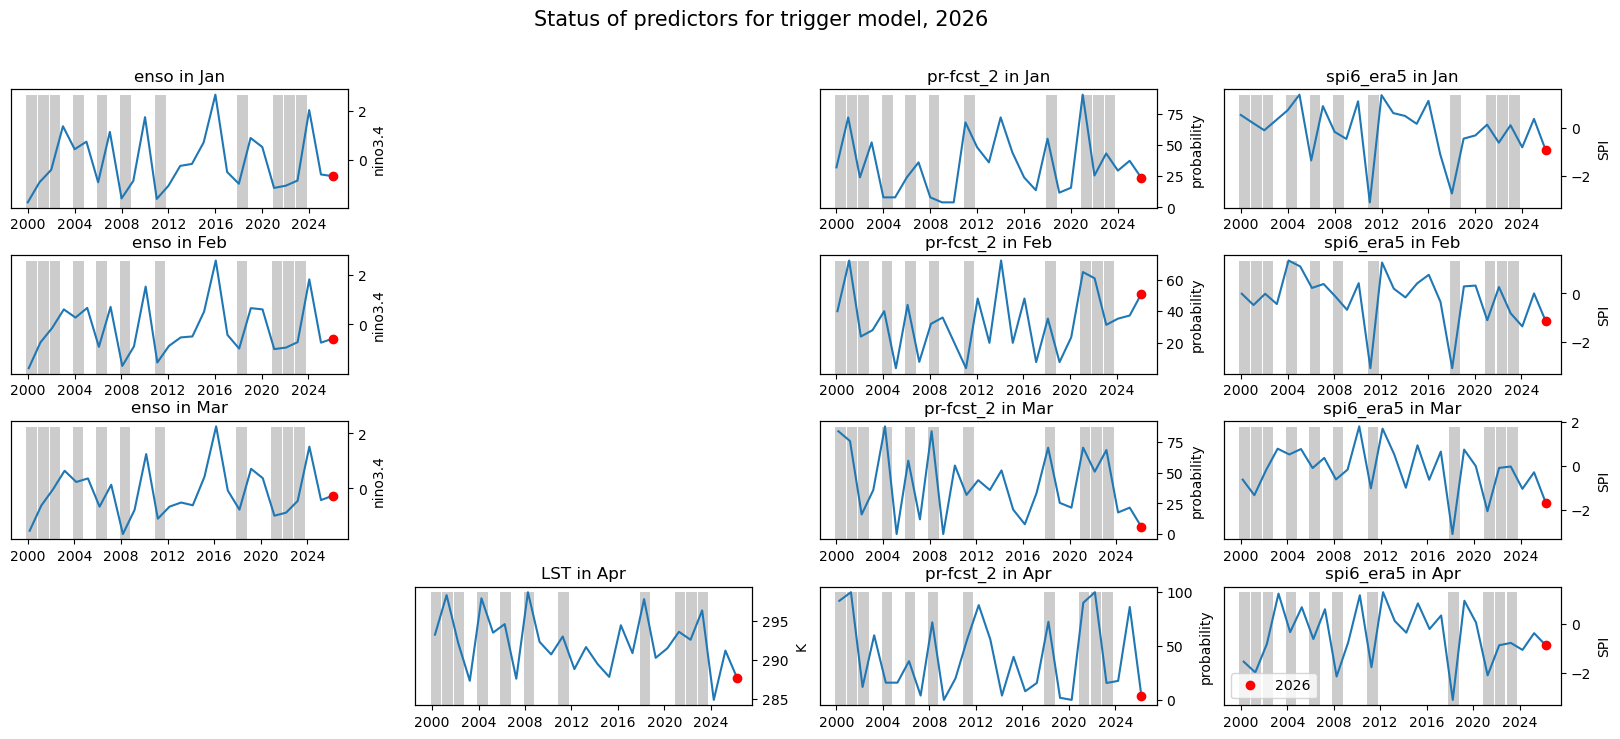

In [14]:
#plot predictors
#
fig=plt.figure(figsize=(20,8))
vars2plot=["enso","LST","pr-fcst_2", "spi6_era5"]

units={'enso':"nino3.4", "LST" : "K", "pr-fcst_2": "probability", "spi6_era5":"SPI"}
i=0
y=droughtsMay.copy()
drop=[2, 6, 10, 13]

for ii,tgtmon in enumerate([1,2,3,4]):
    for var in vars2plot:
        i=i+1
        if i not in drop:
            pl=fig.add_subplot(4,4,i)
            pl2=pl.twinx()
            pl2.plot(alldata[alldata.index.month==tgtmon].index, alldata[alldata.index.month==tgtmon].xs(reg, level="province", axis=1)[var])
            pl2.plot(alldata[alldata.index.month==tgtmon].index[-1], alldata[alldata.index.month==tgtmon].xs(reg, level="province", axis=1)[var][-1], "o", color="red", label=str(year))
            plt.xticks(rotation=90)
            pl.set_title("{} in {}".format(var, monthnames[tgtmon-1]))
            pl.bar(y.index, y.values, width=330, color="0.8", label="drought events\n (calendar year)")
            pl.set_yticks([])
            pl2.set_ylabel(units[var])
plt.legend()        
plt.subplots_adjust(wspace=0.2, hspace=0.4)
plt.suptitle("Status of predictors for trigger model, {}".format(year,monthnames[month]), fontsize=15)
#pl.text(-3.5,0, "Note: predictors for April forecast not yet available", transform=pl.transAxes)
plt.savefig("./figures/predictors_{}{}.jpg".format(year,str(month).zfill(2)))
plt.show()